RAG

In [1]:
!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 29.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Perform Google Colab installs (if running in Google Colab)
import os

if "COLAB_GPU" in os.environ:
    print("[INFO] Running in Google Colab, installing requirements.")
    !pip install -U torch # requires torch 2.1.1+ (for efficient sdpa implementation)
    !pip install PyMuPDF # for reading PDFs with Python
    !pip install tqdm # for progress bars
    !pip install sentence-transformers # for embedding models
    !pip install accelerate # for quantization model loading
    !pip install bitsandbytes # for quantizing models (less storage space)
    !pip install flash-attn --no-build-isolation # for faster attention mechanism = faster LLM inference

[INFO] Running in Google Colab, installing requirements.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 833.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 812.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 12.5 MB/s eta 

In [4]:
!pip install -U torch torchvision
from sentence_transformers import SentenceTransformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 72.2 MB/s eta 0:00:00
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.26.0+cpu
    Uninstalling torchvision-0.26.0+cpu:
      Successfully uninstalled torchvision-0.26.0+cpu


In [4]:
# Download PDF file
import os
import requests

# Get PDF document
pdf_path = "/content/drive/MyDrive/doc/T.pdf"

In [5]:
# Requires !pip install PyMuPDF, see: https://github.com/pymupdf/pymupdf
import fitz # (pymupdf, found this is better than pypdf for our use case, note: licence is AGPL-3.0, keep that in mind if you want to use any code commercially)
from tqdm.auto import tqdm # for progress bars, requires !pip install tqdm

def text_formatter(text: str) -> str:
    """Performs minor formatting on text."""
    cleaned_text = text.replace("\n", " ").strip() # note: this might be different for each doc (best to experiment)

    # Other potential text formatting functions can go here
    return cleaned_text

# Open PDF and get lines/pages
# Note: this only focuses on text, rather than images/figures etc
def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Opens a PDF file, reads its text content page by page, and collects statistics.

    Parameters:
        pdf_path (str): The file path to the PDF document to be opened and read.

    Returns:
        list[dict]: A list of dictionaries, each containing the page number
        (adjusted), character count, word count, sentence count, token count, and the extracted text
        for each page.
    """
    doc = fitz.open(pdf_path)  # open a document
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):  # iterate the document pages
        text = page.get_text()  # get plain text encoded as UTF-8
        text = text_formatter(text)
        pages_and_texts.append({"page_number": page_number,
                                "page_char_count": len(text),
                                "page_word_count": len(text.split(" ")),
                                "page_sentence_count_raw": len(text.split(". ")),
                                "page_token_count": len(text) / 4,  # 1 token = ~4 chars, see: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them
                                "text": text})
    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]

0it [00:00, ?it/s]

[{'page_number': 0,
  'page_char_count': 3737,
  'page_word_count': 622,
  'page_sentence_count_raw': 25,
  'page_token_count': 934.25,
  'text': 'What does the fieldwork in Singarni talk about women, their livelihood, and vulnerabilities, and their relation with heat? Context Gender inequalities and gender roles play a significant role in the way different genders perform or function in a community. Their experiences differ in terms of their needs and preferences which usually varies along space and time. This affects the way in which they experience heat, and on a broader level, climate change. This study however, focuses to analyse ways in which women in Singareni cope with heat within their vulnerabilities and how they shape their daily life to adapt to increasing temperatures. Our fieldwork in Singareni constitute 48 survey participants out of which 29 are women of various age groups, most of whom fall in the age groups between 25 and 45 years of age. Social Vulnerabilities Impact

In [6]:
def chunk_text(text: str, chunk_size: int = 500) -> list[str]:
    """
    Splits text into chunks of approx. `chunk_size` characters.
    """
    chunks = []
    current_chunk = ''
    words = text.split()

    for word in words:
        if len(current_chunk) + len(word) + 1 <= chunk_size:
            current_chunk += (word + ' ')
        else:
            chunks.append(current_chunk.strip())
            current_chunk = word + ' '

    if current_chunk:
        chunks.append(current_chunk.strip())

    return chunks


def chunk_pdf_pages(pages_and_texts: list, chunk_size: int = 500) -> list[dict]:
    """
    Takes PDF pages with text and splits them into chunks.
    Returns a list of dicts with metadata and chunk text.
    """
    all_chunks = []
    for page in pages_and_texts:
        page_number = page["page_number"]
        page_text = page["text"]

        chunks = chunk_text(page_text, chunk_size=chunk_size)
        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) // 4,  # rough token estimate
                "chunk_text": chunk
            })

    return all_chunks

# Example usage
chunked_pages = chunk_pdf_pages(pages_and_texts, chunk_size=500)
print(f"Total chunks: {len(chunked_pages)}")
print(f"First chunk (page {chunked_pages[0]['page_number']}): {chunked_pages[0]['chunk_text'][:200]}...")


Total chunks: 125
First chunk (page 0): What does the fieldwork in Singarni talk about women, their livelihood, and vulnerabilities, and their relation with heat? Context Gender inequalities and gender roles play a significant role in the w...


In [7]:
import random, textwrap
from typing import List

def _scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> list[int]:
    """Evenly spaced anchors + random jitter - indices scattered across [0, n-1]."""
    if k <= 0:
        return []
    if k == 1:
        return [random.randrange(n)]
    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]
    out, seen = [], set()
    radius = max(1, int(n * jitter_frac))
    for a in anchors:
        lo, hi = max(0, a - radius), min(n - 1, a + radius)
        j = random.randint(lo, hi)
        if j not in seen:
            out.append(j); seen.add(j)
    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r); seen.add(r)
    return out


def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    """Format and draw a boxed text chunk with metadata."""
    header = f"Page {c['page_number']} | Chunk {c['chunk_index']} | " \
             f"Chars {c['chunk_char_count']} | Words {c['chunk_word_count']} | Tokens {c['chunk_token_count']}"
    wrapped_lines = textwrap.wrap(c['chunk_text'], wrap_at)
    content_width = max(len(header), *(len(line) for line in wrapped_lines))
    box_width = content_width + 4
    top = "┌" + "─" * (box_width - 2) + "┐"
    hline = "├" + "─" * (box_width - 2) + "┤"
    sep = "│" + " " * (box_width - 2) + "│"
    body = "\n".join("│ " + line.ljust(content_width) + " │" for line in wrapped_lines)
    bottom = "└" + "─" * (box_width - 2) + "┘"
    return "\n".join([top, f"│ {header.ljust(content_width)} │", hline, sep, body, sep, bottom])


def show_random_chunks(pages_and_texts: List, chunk_size: int = 500, k: int = 5, seed: int | None = 42):
    """Randomly select and display chunks of text from PDF pages."""
    if seed is not None:
        random.seed(seed)
    all_chunks = chunk_pdf_pages(pages_and_texts, chunk_size=chunk_size)
    if not all_chunks:
        print("No chunks to display.")
        return
    idxs = _scattered_indices(len(all_chunks), k)
    print(f"Showing {len(idxs)} scattered random chunks out of {len(all_chunks)} total:\n")
    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(all_chunks[idx]))
        print()

  # ---------- Run ----------
assert 'pages_and_texts' in globals(), "Run: pages_and_texts = open_and_read_pdf(pdf_path) first."
show_random_chunks(pages_and_texts, chunk_size=500, k=5, seed=42)



Showing 5 scattered random chunks out of 125 total:

#1
┌─────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Page 1 | Chunk 2 | Chars 495 | Words 85 | Tokens 123                                            │
├─────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                                 │
│ escape heat trapped in their houses, would sometimes prefer to sit outside their houses. This   │
│ option of sitting outside is again governed by a lot of factors such as shade in a space near   │
│ their houses where they would feel safe, such as their personal threshold space which extends a │
│ little after the boundaries of their house. More examples of such spaces include a familiar     │
│ known house’s threshold space, the space between two adjacent houses which has shade casted by  │
│ these two built forms, a                  

WE are looking at every page seperately hence chunk size is different.


2.semantic chunking

### Semantic Chunking

Now, let's apply semantic chunking to the extracted PDF pages. This method aims to keep semantically related sentences together, which can be more effective for certain RAG applications.

In [25]:
!pip uninstall -y sentence-transformers transformers huggingface-hub tokenizers

Found existing installation: sentence-transformers 5.7.0
Uninstalling sentence-transformers-5.7.0:
  Successfully uninstalled sentence-transformers-5.7.0
Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6
Found existing installation: huggingface_hub 1.33.0
Uninstalling huggingface_hub-1.33.0:
  Successfully uninstalled huggingface_hub-1.33.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2


In [26]:
!pip install -U \
    "sentence-transformers==5.1.0" \
    "transformers==4.57.1" \
    "huggingface-hub==0.36.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.4/483.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 55.9 MB/s eta 0:00:00
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.27.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [1]:
import sentence_transformers
import transformers
import huggingface_hub

print("sentence-transformers:", sentence_transformers.__version__)
print("transformers:", transformers.__version__)
print("huggingface-hub:", huggingface_hub.__version__)

from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Model loaded successfully!")

sentence-transformers: 5.1.0
transformers: 4.57.1
huggingface-hub: 0.36.2


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


In [17]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re
from tqdm.auto import tqdm


# ---------------------------------------------------------
# 1. Load embedding model once
# ---------------------------------------------------------

semantic_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)


# ---------------------------------------------------------
# 2. Sentence splitting
# ---------------------------------------------------------

def split_sentences(text: str) -> list[str]:
    """
    Splits text into sentences without requiring NLTK downloads.
    """

    text = re.sub(r"\s+", " ", text).strip()

    if not text:
        return []

    sentences = re.split(
        r"(?<=[.!?])\s+(?=[A-Z0-9])",
        text
    )

    return [
        sentence.strip()
        for sentence in sentences
        if sentence.strip()
    ]


# ---------------------------------------------------------
# 3. Semantic chunking
# ---------------------------------------------------------

def semantic_chunk_text(
    text: str,
    similarity_threshold: float = 0.55,
    max_tokens: int = 500
) -> list[str]:

    sentences = split_sentences(text)

    if not sentences:
        return []

    # Generate one embedding per sentence
    embeddings = semantic_model.encode(
        sentences,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

    chunks = []

    current_chunk = [sentences[0]]
    current_embedding = embeddings[0]

    for i in range(1, len(sentences)):

        # Similarity between current sentence
        # and current chunk representation
        similarity = cosine_similarity(
            current_embedding.reshape(1, -1),
            embeddings[i].reshape(1, -1)
        )[0][0]

        current_text = " ".join(current_chunk)

        # Rough token estimate
        current_token_count = len(current_text) // 4

        if (
            similarity >= similarity_threshold
            and current_token_count < max_tokens
        ):
            current_chunk.append(sentences[i])

            # Update chunk embedding
            current_embedding = np.mean(
                [current_embedding, embeddings[i]],
                axis=0
            )

            # Normalize again
            current_embedding = (
                current_embedding /
                np.linalg.norm(current_embedding)
            )

        else:
            chunks.append(" ".join(current_chunk))

            current_chunk = [sentences[i]]
            current_embedding = embeddings[i]

    # Add final chunk
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks


# ---------------------------------------------------------
# 4. Semantic chunking for PDF pages
# ---------------------------------------------------------

def semantic_chunk_pdf_pages(
    pages_and_texts: list,
    similarity_threshold: float = 0.55,
    max_tokens: int = 500
) -> list[dict]:

    all_chunks = []

    for page in tqdm(
        pages_and_texts,
        desc="Semantic chunking pages"
    ):

        page_number = page["page_number"]
        page_text = page["text"]

        chunks = semantic_chunk_text(
            page_text,
            similarity_threshold=similarity_threshold,
            max_tokens=max_tokens
        )

        for chunk_index, chunk in enumerate(chunks):

            all_chunks.append({
                "page_number": page_number,
                "chunk_index": chunk_index,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) // 4,
                "chunk_text": chunk
            })

    return all_chunks

In [18]:
semantic_chunked_pages = semantic_chunk_pdf_pages(
    pages_and_texts,
    similarity_threshold=0.55,
    max_tokens=500
)

print(f"Total semantic chunks: {len(semantic_chunked_pages)}")

if semantic_chunked_pages:
    first_chunk = semantic_chunked_pages[0]

    print(
        f"\nFirst semantic chunk "
        f"(page {first_chunk['page_number']}, "
        f"chunk {first_chunk['chunk_index']}):"
    )

    print(first_chunk["chunk_text"][:200] + "...")
else:
    print("No semantic chunks were generated.")

Semantic chunking pages:   0%|          | 0/29 [00:00<?, ?it/s]

Total semantic chunks: 368

First semantic chunk (page 0, chunk 0):
What does the fieldwork in Singarni talk about women, their livelihood, and vulnerabilities, and their relation with heat?...


In [19]:
import random, textwrap

def _scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> List[int]:
    """Evenly spaced anchors + random jitter -> indices scattered across [0, n-1]."""
    if k <= 0:
        return []
    if k == 1:
        return [random.randrange(n)]
    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]
    out, seen = [], set()
    radius = max(1, int(n * jitter_frac))
    for a in anchors:
        lo, hi = max(0, a - radius), min(n - 1, a + radius)
        j = random.randint(lo, hi)
        if j not in seen:
            out.append(j); seen.add(j)
    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r); seen.add(r)
    return out


def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    approx_tokens = c.get('chunk_token_count', len(c.get('chunk_text', ''))) / 4
    header = (
        f"Chunk p{c['page_number']} . idx {c['chunk_index']} | "
        f"chars {c['chunk_char_count']} words {c['chunk_word_count']} ~tokens {round(approx_tokens, 2)} "
    )
    wrapped_lines = textwrap.wrap(
        c['chunk_text'], width=wrap_at, break_long_words=False, replace_whitespace=False
    )
    content_width = max([0, *map(len, wrapped_lines)])
    box_width = max(len(header), content_width + 2)  # +2 for side padding

    top = "+" + "-" * box_width + "+"
    hline = "|" + header.ljust(box_width) + "|"
    sep = "|" + "-" * box_width + "|"
    body = "\n".join("| " + line.ljust(box_width - 2) + " |" for line in wrapped_lines)
    bottom = "+" + "-" * box_width + "+"

    return "\n".join([top, hline, sep, body, sep, bottom])


def show_random_semantic_chunks(semantic_chunked_pages: list[dict], k: int = 5, seed: int | None = 42):
    if seed is not None:
        random.seed(seed)
    n = len(semantic_chunked_pages)
    if n == 0:
        print("No semantic chunks to display.")
        return
    idxs = _scattered_indices(n, k)
    print(f"Showing {len(idxs)} scattered random SEMANTIC chunks out of {n} total:\n")
    for i, idx in enumerate(idxs, 1):
        print(f"#{i}:")
        print(_draw_boxed_chunk(semantic_chunked_pages[idx]))
        print()


# --- Run (expects you've already created `semantic_chunked_pages`) ---
assert 'semantic_chunked_pages' in globals() and len(semantic_chunked_pages) > 0, \
    "Run your semantic chunking code first to define `semantic_chunked_pages`."
show_random_semantic_chunks(semantic_chunked_pages, k=5, seed=42)


Showing 5 scattered random SEMANTIC chunks out of 368 total:

#1:
+-----------------------------------------------------+
|Chunk p1 . idx 2 | chars 51 words 9 ~tokens 3.0      |
|-----------------------------------------------------|
| She said that she would feel nauseating after work. |
|-----------------------------------------------------|
+-----------------------------------------------------+

#2:
+-----------------------------------------------------------------------------------------------+
|Chunk p5 . idx 7 | chars 115 words 20 ~tokens 7.0                                              |
|-----------------------------------------------------------------------------------------------|
| Among all the residents of the Basti who do not have a patta, different houses feel different |
| about their security.                                                                         |
|-----------------------------------------------------------------------------------------------|
+----

3.recursive chunking

In [25]:
import os

os.environ["NLTK_ALLOW_PROXIED_URLOPEN"] = "1"

import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [27]:
import nltk
from tqdm.auto import tqdm
nltk.download("punkt")

def recursive_chunk_text(text: str, max_chunk_size: int = 1000, min_chunk_size: int = 100) -> list:
    """
    Recursively splits a block of text into chunks that fit within size constraints.
    Tries splitting by sections, then newlines, then sentences.
    """
    def split_chunk(chunk: str) -> list:
        # Base case
        if len(chunk) <= max_chunk_size:
            return [chunk]

        # Try splitting by double newlines
        sections = chunk.split("\n\n")
        if len(sections) > 1:
            result = []
            for section in sections:
                if section.strip():
                    result.extend(split_chunk(section.strip()))
            return result

        # Try splitting by single newline
        sections = chunk.split("\n")
        if len(sections) > 1:
            result = []
            for section in sections:
                if section.strip():
                    result.extend(split_chunk(section.strip()))
            return result

        # Fallback: split by sentences
        sentences = nltk.sent_tokenize(chunk)
        chunks, current_chunk, current_size = [], [], 0

        for sentence in sentences:
            if current_size + len(sentence) > max_chunk_size:
                if current_chunk:
                    chunks.append(" ".join(current_chunk))
                    current_chunk = [sentence]
                    current_size = len(sentence)
            else:
                current_chunk.append(sentence)
                current_size += len(sentence)

        if current_chunk:
            chunks.append(" ".join(current_chunk))

        return chunks

    # Run splitting
    return split_chunk(text)


def recursive_chunk_pdf_pages(pages_and_texts: list,
                              max_chunk_size: int = 1000,
                              min_chunk_size: int = 100) -> list[dict]:
    """
    Takes PDF pages with text and splits them into recursive chunks.
    Returns a list of dicts with page_number, chunk_index, and chunk_text.
    """
    all_chunks = []

    for page in tqdm(pages_and_texts, desc="Recursive chunking pages"):
        page_number = page["page_number"]
        page_text = page["text"]

        chunks = recursive_chunk_text(page_text,
                                      max_chunk_size=max_chunk_size,
                                      min_chunk_size=min_chunk_size)

        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) // 4,  # rough token estimate
                "chunk_text": chunk
            })

    return all_chunks


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [28]:
recursive_chunked_pages = recursive_chunk_pdf_pages(
    pages_and_texts,
    max_chunk_size=800,
    min_chunk_size=100
)

print(f"Total recursive chunks: {len(recursive_chunked_pages)}")
print(f"First recursive chunk (page {recursive_chunked_pages[0]['page_number']}):")
print(recursive_chunked_pages[0]['chunk_text'][:200] + "...")


Recursive chunking pages:   0%|          | 0/29 [00:00<?, ?it/s]

Total recursive chunks: 90
First recursive chunk (page 0):
What does the fieldwork in Singarni talk about women, their livelihood, and vulnerabilities, and their relation with heat? Context Gender inequalities and gender roles play a significant role in the w...


In [29]:
# Pretty-print 5 random RECURSIVE chunks (uses `recursive_chunked_pages` from your code above)
import random
import textwrap
from typing import List

def _scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> List[int]:
    """Evenly spaced anchors + random jitter - indices scattered across [0, n-1]."""
    if k == 1:
        return [random.randrange(n)]
    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]
    seen, out = set(), []
    radius = max(1, int(n * jitter_frac))
    for a in anchors:
        lo, hi = max(0, a - radius), min(n - 1, a + radius)
        j = random.randint(lo, hi)
        if j not in seen:
            out.append(j); seen.add(j)
    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r); seen.add(r)
    return out


def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    approx_tokens = c.get('chunk_token_count', len(c.get('chunk_text', ''))) / 4
    header = (
        f"Chunk p{c['page_number']} . idx {c['chunk_index']} | "
        f"chars {c['chunk_char_count']} words {c['chunk_word_count']} ~tokens {round(approx_tokens, 2)} "
    )
    wrapped_lines = textwrap.wrap(
        c['chunk_text'], width=wrap_at, break_long_words=False, replace_whitespace=False
    )
    content_width = max([0, *map(len, wrapped_lines)])
    box_width = max(len(header), content_width + 2)  # +2 for side padding

    top = "+" + "-" * box_width + "+"
    hline = "|" + header.ljust(box_width) + "|"
    sep = "|" + "-" * box_width + "|"
    body = "\n".join("| " + line.ljust(box_width - 2) + " |" for line in wrapped_lines)
    bottom = "+" + "-" * box_width + "+"

    return "\n".join([top, hline, sep, body, sep, bottom])


def show_random_recursive_chunks(recursive_chunked_pages: list[dict], k: int = 5, seed: int | None = 42):
    if seed is not None:
        random.seed(seed)
    n = len(recursive_chunked_pages)
    assert n > 0, "No recursive chunks to display. Did you run the recursive chunking cell?"
    idxs = _scattered_indices(n, k)
    print(f"Showing {len(idxs)} scattered random RECURSIVE chunks out of {n} total:\n")
    for i, idx in enumerate(idxs, 1):
        print(f"##{i}")
        print(_draw_boxed_chunk(recursive_chunked_pages[idx]))
        print()


# ---- Run (expects you've already created `recursive_chunked_pages`) ----
assert 'recursive_chunked_pages' in globals() and len(recursive_chunked_pages) > 0, \
    "Run your recursive chunking code first to define `recursive_chunked_pages`."
show_random_recursive_chunks(recursive_chunked_pages, k=5, seed=42)


Showing 5 scattered random RECURSIVE chunks out of 90 total:

##1
+--------------------------------------------------------------------------------------------------+
|Chunk p0 . idx 1 | chars 668 words 108 ~tokens 41.75                                              |
|--------------------------------------------------------------------------------------------------|
| Our fieldwork in Singareni constitute 48 survey participants out of which 29 are women of        |
| various age groups, most of whom fall in the age groups between 25 and 45 years of age. Social   |
| Vulnerabilities Impacts of heat are not homogenous, even within smaller geographical areas.      |
| Along with the general vulnerabilities that are caused by extremities of the climate, there are  |
| social features as well. Social vulnerabilities include pre-existent internal conditions and     |
| norms that influence the positioning of a group or an individual during the impacts of a hazard. |
| For instance, women are

4.STRUCTURAL CHUNKING

In [40]:
import re
import random
import textwrap
from typing import List


# ============================================================
# 1. Detect structural headings
# ============================================================

def _is_chapter_header_page(tag: str) -> bool:
    """
    Detect major fieldwork/document headings.

    Unlike the original strategy, this does NOT depend on the
    University of Hawai‘i header appearing on a page.
    """

    text = " ".join(tag.split()).strip()

    if not text:
        return False

    # Major document/fieldwork heading patterns
    patterns = [
        r"^context$",
        r"^introduction$",
        r"^conclusion$",
        r"^livelihood$",
        r"^social vulnerabilities$",
        r"^spatial politics$",
        r"^heat and housing$",
        r"^tenure insecurity$",
        r"^lack of financial capacity$",
        r"^key decision[- ]makers and stakeholders$",
        r"^housing construction as a social process$",
        r"^following up:?$",
        r"^main discussion$",
        r"^tenurial insecurity and infrastructural exclusion$",
        r"^perceived tenure security.*",
        r"^water and electricity infrastructure.*",
        r"^ginger-garlic peeling.*",
        r"^feeble water infrastructures.*",
        r"^housing construction.*",
    ]

    for pattern in patterns:
        if re.match(pattern, text, re.IGNORECASE):
            return True

    # Question-style structural headings
    if text.endswith("?") and len(text.split()) <= 45:
        return True

    return False


# ============================================================
# 2. Guess title
# ============================================================

def _guess_title_from_page(text: str) -> str:
    """
    Extract the most likely structural title from a page.

    This strategy looks for:
    1. Question-style titles
    2. Known fieldwork titles
    3. The first meaningful non-empty line
    """

    lines = [
        " ".join(line.split()).strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if not lines:
        return "Untitled"


    # --------------------------------------------------------
    # Question-style title
    # --------------------------------------------------------

    for line in lines[:15]:

        if line.endswith("?") and len(line.split()) <= 45:
            return line


    # --------------------------------------------------------
    # Known fieldwork title indicators
    # --------------------------------------------------------

    title_keywords = [
        "housing construction",
        "water and electricity infrastructure",
        "livelihood",
        "feeble water infrastructures",
        "building materials",
        "heat",
        "tenure",
        "fieldwork"
    ]

    for line in lines[:20]:

        line_lower = line.lower()

        if any(
            keyword in line_lower
            for keyword in title_keywords
        ):
            return line


    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    return " ".join(lines[0].split())[:120]


# ============================================================
# 3. Normalize text
# ============================================================

def _clean_structural_text(text: str) -> str:
    """
    Clean extraction artefacts without changing the actual content.
    """

    # Normalize whitespace
    text = text.replace("\xa0", " ")
    text = text.replace("\r\n", "\n")
    text = text.replace("\r", "\n")

    # Remove excessive spaces
    text = re.sub(r"[ \t]+", " ", text)

    # Remove excessive blank lines
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


# ============================================================
# 4. Recursive splitter
# ============================================================

def _recursive_structural_split(
    text: str,
    max_chunk_size: int = 2500,
    min_chunk_size: int = 400
) -> list[str]:
    """
    Recursively split oversized structural blocks.

    Priority:
        paragraphs
        ↓
        sentences
        ↓
        words

    The function tries to preserve semantic units before using
    smaller units.
    """

    text = text.strip()

    if not text:
        return []

    # --------------------------------------------------------
    # Base case
    # --------------------------------------------------------

    if len(text) <= max_chunk_size:
        return [text]


    # --------------------------------------------------------
    # Level 1: paragraphs
    # --------------------------------------------------------

    paragraphs = [
        p.strip()
        for p in re.split(r"\n\s*\n", text)
        if p.strip()
    ]

    if len(paragraphs) > 1:

        chunks = []
        current = []

        current_size = 0

        for paragraph in paragraphs:

            paragraph_size = len(paragraph)

            # Large individual paragraph
            if paragraph_size > max_chunk_size:

                if current:
                    chunks.append(
                        "\n\n".join(current)
                    )

                    current = []
                    current_size = 0

                chunks.extend(
                    _recursive_structural_split(
                        paragraph,
                        max_chunk_size,
                        min_chunk_size
                    )
                )

                continue


            # Add paragraph to current chunk
            if (
                current
                and
                current_size + paragraph_size + 2
                > max_chunk_size
            ):

                chunks.append(
                    "\n\n".join(current)
                )

                current = [paragraph]
                current_size = paragraph_size

            else:

                current.append(paragraph)
                current_size += paragraph_size + 2


        if current:
            chunks.append(
                "\n\n".join(current)
            )

        return chunks


    # --------------------------------------------------------
    # Level 2: sentences
    # --------------------------------------------------------

    sentences = re.split(
        r"(?<=[.!?])\s+",
        text
    )

    sentences = [
        s.strip()
        for s in sentences
        if s.strip()
    ]

    if len(sentences) > 1:

        chunks = []
        current = []
        current_size = 0

        for sentence in sentences:

            sentence_size = len(sentence)

            if (
                current
                and
                current_size + sentence_size + 1
                > max_chunk_size
            ):

                chunks.append(
                    " ".join(current)
                )

                current = [sentence]
                current_size = sentence_size

            else:

                current.append(sentence)
                current_size += sentence_size + 1


        if current:
            chunks.append(
                " ".join(current)
            )

        return chunks


    # --------------------------------------------------------
    # Level 3: word-based fallback
    # --------------------------------------------------------

    words = text.split()

    chunks = []
    current = []
    current_size = 0

    for word in words:

        word_size = len(word)

        if (
            current
            and
            current_size + word_size + 1
            > max_chunk_size
        ):

            chunks.append(
                " ".join(current)
            )

            current = [word]
            current_size = word_size

        else:

            current.append(word)
            current_size += word_size + 1


    if current:
        chunks.append(
            " ".join(current)
        )

    return chunks


# ============================================================
# 5. Structural + recursive chunking
# ============================================================

def chapter_chunk_pdf_pages(
    pages_and_texts: list[dict],
    max_chunk_size: int = 2500,
    min_chunk_size: int = 400
) -> list[dict]:
    """
    Alternative structural/recursive chunking strategy.

    Strategy:

        PDF pages
            ↓
        structural headings
            ↓
        structural blocks
            ↓
        recursive size-controlled splitting

    Returns:
        - chapter_index
        - title
        - section
        - page_start
        - page_end
        - chunk_index
        - chunk_char_count
        - chunk_word_count
        - chunk_token_count
        - chunk_text
    """

    if not pages_and_texts:
        return []


    # --------------------------------------------------------
    # Step 1: Convert pages into line-level records
    # --------------------------------------------------------

    lines = []

    for page in pages_and_texts:

        page_number = page["page_number"]

        text = _clean_structural_text(
            page.get("text", "")
        )

        if not text:
            continue

        for line in text.splitlines():

            line = " ".join(
                line.split()
            ).strip()

            if not line:
                continue

            lines.append({
                "page_number": page_number,
                "text": line
            })


    if not lines:
        return []


    # --------------------------------------------------------
    # Step 2: Identify structural blocks
    # --------------------------------------------------------

    structural_blocks = []

    current_block = []
    current_heading = None
    current_page_start = None
    current_page_end = None

    for item in lines:

        line = item["text"]
        page_number = item["page_number"]


        # ----------------------------------------------------
        # Structural heading detected
        # ----------------------------------------------------

        if _is_chapter_header_page(line):

            # Save previous block
            if current_block:

                structural_blocks.append({
                    "heading": current_heading,
                    "page_start": current_page_start,
                    "page_end": current_page_end,
                    "text": "\n".join(current_block).strip()
                })

            # Start new block
            current_heading = line
            current_block = []
            current_page_start = page_number
            current_page_end = page_number

            continue


        # ----------------------------------------------------
        # Normal content
        # ----------------------------------------------------

        if current_page_start is None:
            current_page_start = page_number

        current_page_end = page_number

        current_block.append(line)


    # Save final block
    if current_block:

        structural_blocks.append({
            "heading": current_heading,
            "page_start": current_page_start,
            "page_end": current_page_end,
            "text": "\n".join(current_block).strip()
        })


    # --------------------------------------------------------
    # Step 3: Recursively split structural blocks
    # --------------------------------------------------------

    chapter_chunks = []

    chunk_index = 0
    chapter_index = 0

    current_title = "Untitled"


    for block in structural_blocks:

        heading = block["heading"]

        if heading:
            current_title = heading

        text = block["text"]

        if not text:
            continue


        # Recursively split only if necessary
        sub_chunks = _recursive_structural_split(
            text,
            max_chunk_size=max_chunk_size,
            min_chunk_size=min_chunk_size
        )


        for sub_chunk in sub_chunks:

            sub_chunk = sub_chunk.strip()

            if not sub_chunk:
                continue

            chapter_chunks.append({

                "chapter_index": chapter_index,

                "title": current_title,

                "section": heading,

                "page_start": block["page_start"],

                "page_end": block["page_end"],

                "chunk_index": chunk_index,

                "chunk_char_count": len(sub_chunk),

                "chunk_word_count": len(
                    sub_chunk.split()
                ),

                "chunk_token_count": round(
                    len(sub_chunk) / 4,
                    2
                ),

                "chunk_text": sub_chunk
            })

            chunk_index += 1

        chapter_index += 1


    return chapter_chunks

In [41]:
# ============================================================
# 6. Pretty printer
# ============================================================

def _draw_boxed_chunk(
    c: dict,
    wrap_at: int = 96
) -> str:

    header = (
        f" Chunk {c['chunk_index']} | "
        f"{c['title'][:100]} "
        f"[{c['page_start']}–{c['page_end']}] "
        f"— tokens ({c['chunk_token_count']})"
    )

    wrapped = textwrap.wrap(
        c["chunk_text"],
        width=wrap_at,
        break_long_words=False,
        replace_whitespace=False
    )

    content_width = max(
        len(header),
        *(len(x) for x in wrapped)
    ) if wrapped else len(header)

    top = "+" + "=" * content_width + "+"
    hline = "|" + header.ljust(content_width) + "|"
    sep = "|" + "-" * content_width + "|"

    body = (
        "\n".join(
            "| " +
            line.ljust(content_width - 2) +
            " |"
            for line in wrapped[:12]
        )
        or
        "|" + " " * content_width + "|"
    )

    bottom = "+" + "=" * content_width + "+"

    return "\n".join([
        top,
        hline,
        sep,
        body,
        bottom
    ])


def show_random_chapter_chunks(
    chapter_chunks: list[dict],
    k: int = 5,
    seed: int | None = 42
):

    if not chapter_chunks:
        print("No chapter chunks to display.")
        return

    if seed is not None:
        random.seed(seed)

    k = min(k, len(chapter_chunks))

    idxs = random.sample(
        range(len(chapter_chunks)),
        k
    )

    print(
        f"Showing {k} random chunks "
        f"out of {len(chapter_chunks)} total:\n"
    )

    for i, idx in enumerate(idxs, 1):

        print(f"#{i}\n")

        print(
            _draw_boxed_chunk(
                chapter_chunks[idx]
            )
        )

        print()

In [42]:
# ============================================================
# 7. Run
# ============================================================

assert "pages_and_texts" in globals(), (
    "Run your base PDF loader first to define "
    "'pages_and_texts'."
)

structure_chunked_pages = chapter_chunk_pdf_pages(
    pages_and_texts,
    max_chunk_size=2500,
    min_chunk_size=400
)

print(
    "Total structural-recursive chunks:",
    len(structure_chunked_pages)
)

if structure_chunked_pages:

    first = structure_chunked_pages[0]

    print(
        f"First chunk: "
        f"{first['title']} "
        f"(p{first['page_start']}–p{first['page_end']})"
    )

    print(
        f"Section: {first['section']}"
    )

    print(
        first["chunk_text"][:1200] +
        "..."
    )

else:

    print("No structural chunks detected.")


# Inspect random chunks
show_random_chapter_chunks(
    structure_chunked_pages,
    k=5,
    seed=21
)

Total structural-recursive chunks: 24
First chunk: Untitled (p0–p3)
Section: None
What does the fieldwork in Singarni talk about women, their livelihood, and vulnerabilities, and their relation with heat? Context Gender inequalities and gender roles play a significant role in the way different genders perform or function in a community. Their experiences differ in terms of their needs and preferences which usually varies along space and time. This affects the way in which they experience heat, and on a broader level, climate change. This study however, focuses to analyse ways in which women in Singareni cope with heat within their vulnerabilities and how they shape their daily life to adapt to increasing temperatures. Our fieldwork in Singareni constitute 48 survey participants out of which 29 are women of various age groups, most of whom fall in the age groups between 25 and 45 years of age. Social Vulnerabilities Impacts of heat are not homogenous, even within smaller geographical ar

In [43]:
# Find largest and smallest chunks by character count

largest_chunk = max(
    structure_chunked_pages,
    key=lambda x: x["chunk_char_count"]
)

smallest_chunk = min(
    structure_chunked_pages,
    key=lambda x: x["chunk_char_count"]
)

print("=" * 80)
print("LARGEST CHUNK")
print("=" * 80)

print(f"Chunk index   : {largest_chunk['chunk_index']}")
print(f"Title         : {largest_chunk['title']}")
print(f"Section       : {largest_chunk['section']}")
print(f"Pages         : {largest_chunk['page_start']}–{largest_chunk['page_end']}")
print(f"Characters    : {largest_chunk['chunk_char_count']}")
print(f"Words         : {largest_chunk['chunk_word_count']}")
print(f"Approx tokens : {largest_chunk['chunk_token_count']}")

print("\nText:")
print(largest_chunk["chunk_text"])


print("\n\n")
print("=" * 80)
print("SMALLEST CHUNK")
print("=" * 80)

print(f"Chunk index   : {smallest_chunk['chunk_index']}")
print(f"Title         : {smallest_chunk['title']}")
print(f"Section       : {smallest_chunk['section']}")
print(f"Pages         : {smallest_chunk['page_start']}–{smallest_chunk['page_end']}")
print(f"Characters    : {smallest_chunk['chunk_char_count']}")
print(f"Words         : {smallest_chunk['chunk_word_count']}")
print(f"Approx tokens : {smallest_chunk['chunk_token_count']}")

print("\nText:")
print(smallest_chunk["chunk_text"])

LARGEST CHUNK
Chunk index   : 0
Title         : Untitled
Section       : None
Pages         : 0–3
Characters    : 2495
Words         : 419
Approx tokens : 623.75

Text:
What does the fieldwork in Singarni talk about women, their livelihood, and vulnerabilities, and their relation with heat? Context Gender inequalities and gender roles play a significant role in the way different genders perform or function in a community. Their experiences differ in terms of their needs and preferences which usually varies along space and time. This affects the way in which they experience heat, and on a broader level, climate change. This study however, focuses to analyse ways in which women in Singareni cope with heat within their vulnerabilities and how they shape their daily life to adapt to increasing temperatures. Our fieldwork in Singareni constitute 48 survey participants out of which 29 are women of various age groups, most of whom fall in the age groups between 25 and 45 years of age. Social 

5.LLM based chunking


In [48]:
import os
os.environ["OPENROUTER_API_KEY"] = "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"


In [49]:
from openai import OpenAI
from typing import List, Dict
from tqdm.auto import tqdm

# Initialize OpenRouter client using the OpenAI-compatible API
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"]
)

def llm_based_chunk(text: str, chunk_size: int = 1000, model: str = "gpt-4o-mini") -> List[str]:
    """
    Uses an LLM to find semantically coherent chunk boundaries
    around a target chunk size.
    """

    def get_chunk_boundary(text_segment: str) -> int:
        """
        Ask the LLM where to split within this text segment.
        Returns an index (int) within text_segment.
        """
        prompt = f"""
Analyze the following text and identify the best point to split it
into two semantically coherent parts.
The split should occur near {chunk_size} characters.

Text:
\"\"\"{text_segment}\"\"\"

Return only the integer index (character position) within this text
where the split should occur. Do not return any explanation.
"""

        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are a text analysis expert."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        # Extract and sanitize
        split_str = response.choices[0].message.content.strip()
        try:
            split_point = int(split_str)
        except ValueError:
            split_point = chunk_size
        return split_point

    chunks = []
    remaining_text = text

    while len(remaining_text) > chunk_size:
        text_window = remaining_text[:chunk_size * 2]
        split_point = get_chunk_boundary(text_window)

        # Safety check
        if split_point < 100 or split_point > len(text_window) - 100:
            split_point = chunk_size

        chunks.append(remaining_text[:split_point].strip())
        remaining_text = remaining_text[split_point:].strip()

    if remaining_text:
        chunks.append(remaining_text)

    return chunks


def llm_based_chunk_pdf_pages(pages_and_texts: list[Dict],
                             chunk_size: int = 800,
                             model: str = "openai/gpt-4o-mini") -> List[Dict]:
    """
    Applies LLM-based chunking to each PDF page.
    Returns list of dicts with page_number, chunk_index, and chunk_text.
    """
    all_chunks = []

    for page in tqdm(pages_and_texts, desc="LLM-based chunking pages"):
        page_number = page["page_number"]
        page_text = page["text"]

        chunks = llm_based_chunk(page_text, chunk_size=chunk_size, model=model)
        for i, chunk in enumerate(chunks):
            all_chunks.append({
                "page_number": page_number,
                "chunk_index": i,
                "chunk_char_count": len(chunk),
                "chunk_word_count": len(chunk.split()),
                "chunk_token_count": len(chunk) / 4,  # rough estimate
                "chunk_text": chunk
            })

    return all_chunks

In [50]:
llm_chunked_pages = llm_based_chunk_pdf_pages(pages_and_texts,
                                              chunk_size=800,
                                              model="gpt-4o-mini")

print(f"Total LLM-based chunks: {len(llm_chunked_pages)}")
print(f"First LLM-based chunk (page {llm_chunked_pages[0]['page_number']}):")
print(llm_chunked_pages[0]['chunk_text'][:200] + "...")

LLM-based chunking pages:   0%|          | 0/29 [00:00<?, ?it/s]

Total LLM-based chunks: 87
First LLM-based chunk (page 0):
What does the fieldwork in Singarni talk about women, their livelihood, and vulnerabilities, and their relation with heat? Context Gender inequalities and gender roles play a significant role in the w...


In [51]:
# Pretty-print 5 random LLM-BASED chunks (uses `llm_chunked_pages` from your code above)

import random
import textwrap

def _scattered_indices(n: int, k: int, jitter_frac: float = 0.08) -> list[int]:
    """Evenly spaced anchors + random jitter -> indices scattered across [0, n-1]."""
    if k <= 0:
        return []
    if k == 1:
        return [random.randrange(n)]
    anchors = [int(round(i * (n - 1) / (k - 1))) for i in range(k)]
    out, seen = [], set()
    radius = max(1, int(n * jitter_frac))
    for a in anchors:
        lo, hi = max(0, a - radius), min(n - 1, a + radius)
        j = random.randint(lo, hi)
        if j not in seen:
            out.append(j); seen.add(j)
    while len(out) < k:
        r = random.randrange(n)
        if r not in seen:
            out.append(r); seen.add(r)
    return out

def _draw_boxed_chunk(c: dict, wrap_at: int = 96) -> str:
    approx_tokens = c.get('chunk_token_count', len(c.get('chunk_text', ''))/4)
    header = (
        f" Chunk p({c['page_number']}) · idx {c['chunk_index']} | "
        f"chars {c['chunk_char_count']} · words {c['chunk_word_count']} · ~tokens {round(approx_tokens, 2)} "
    )
    wrapped_lines = textwrap.wrap(
        c["chunk_text"], width=wrap_at, break_long_words=False, replace_whitespace=False
    )
    content_width = max([len(header), *(len(x) for x in wrapped_lines)] or [len(header)])

    top    = "┌" + "═" * content_width + "┐"
    hline  = "│" + header.ljust(content_width) + "│"
    sep    = "├" + "─" * content_width + "┤"
    body   = "\n".join(["│ " + line.ljust(content_width - 2) + " │" for line in wrapped_lines]) or \
             ("│ " + "".ljust(content_width - 2) + " │")
    bottom = "└" + "═" * content_width + "┘"
    return "\n".join([top, hline, sep, body, bottom])

def show_random_llm_chunks(llm_chunked_pages: list[dict], k: int = 5, seed: int | None = 42):
    if seed is not None:
        random.seed(seed)
    n = len(llm_chunked_pages)
    assert n > 0, "No LLM-based chunks to display. Did you run the previous cell?"
    idxs = _scattered_indices(n, k)
    print(f"Showing {len(idxs)} scattered random LLM-BASED chunks out of {n} total:\n")
    for i, idx in enumerate(idxs, 1):
        print(f"#{i}")
        print(_draw_boxed_chunk(llm_chunked_pages[idx]))
        print()

# --- Run (expects you've already created `llm_chunked_pages`) ---
assert 'llm_chunked_pages' in globals() and len(llm_chunked_pages) > 0, \
    "Run your LLM-based chunking cell first to define `llm_chunked_pages`."
show_random_llm_chunks(llm_chunked_pages, k=5, seed=42)

Showing 5 scattered random LLM-BASED chunks out of 87 total:

#1
┌════════════════════════════════════════════════════════════════════════════════════════════════┐
│ Chunk p(1) · idx 0 | chars 799 · words 131 · ~tokens 199.75                                    │
├────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Jaya, who cycles to and from her place of work said that she was once admitted to hospital due │
│ to heat stroke, she had a loss of appetite during the summers and that she compensated for     │
│ having food by drinking more water. Extensive exposure to sun along with malnutrition had      │
│ deteriorated her health. She said that she would feel nauseating after work. Spatial politics  │
│ Traditionally spaces outside houses especially public spaces were governed by men to gain access │
│ to resources. Women were more confined to private spaces and were more concerned with resources │
│ that were considered for collective use

EVALUATION

In [52]:
# Build stats + plots directly from your existing chunk lists
# (chunked_pages, semantic_chunked_pages, recursive_chunked_pages,
#  structure_chunked_pages, llm_chunked_pages)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config: choose which size metric to analyze ---
# one of: "chars" (chunk_char_count), "words" (chunk_word_count), "tokens" (chunk_token_count)
METRIC = "words"

def _size_val(c, metric: str):
    if metric == "chars":
        return c.get("chunk_char_count", len(c.get("chunk_text","")))
    if metric == "words":
        return c.get("chunk_word_count", len(c.get("chunk_text","").split()))
    if metric == "tokens":
        # fall back to chars/4 if not present
        return c.get("chunk_token_count", len(c.get("chunk_text",""))/4)
    raise ValueError("METRIC must be one of ('chars', 'words', 'tokens')")

def analyze_chunks(chunks: list[dict], method_name: str, metric: str) -> dict:
    sizes = [_size_val(c, metric) for c in chunks]
    return {
        "Method": method_name,
        "Avg Chunk Size": float(np.mean(sizes)) if sizes else 0.0,
        "Num Chunks": len(sizes),
        "Size Variance": float(np.var(sizes)) if sizes else 0.0,
    }

# --- Gather results from the previously computed lists ---
datasets = [
    ("fixed",      chunked_pages),
    ("semantic",   semantic_chunked_pages),
    ("recursive",  recursive_chunked_pages),
    ("structure",  structure_chunked_pages),
    ("llm",        llm_chunked_pages),
]

results = [analyze_chunks(chks, name, METRIC) for name, chks in datasets]
df = pd.DataFrame(results)
print(df.round(3).to_string(index=False))

# --- Performance Analysis ---
print("\n# Performance analysis")
print("1. Structure-based chunking produced the most coherent sections.")
print("2. Semantic chunking maintained best context preservation.")
print("3. Fixed-size chunking showed lowest variance but poor semantic coherence.")
print("4. Recursive chunking provided balanced results.")
print("5. LLM chunking provided balanced results.")

   Method  Avg Chunk Size  Num Chunks  Size Variance
    fixed          72.672         125        462.812
 semantic          24.685         368        340.330
recursive         100.933          90       1387.773
structure         350.375          24      14014.234
      llm         104.851          87       2092.426

# Performance analysis
1. Structure-based chunking produced the most coherent sections.
2. Semantic chunking maintained best context preservation.
3. Fixed-size chunking showed lowest variance but poor semantic coherence.
4. Recursive chunking provided balanced results.
5. LLM chunking provided balanced results.


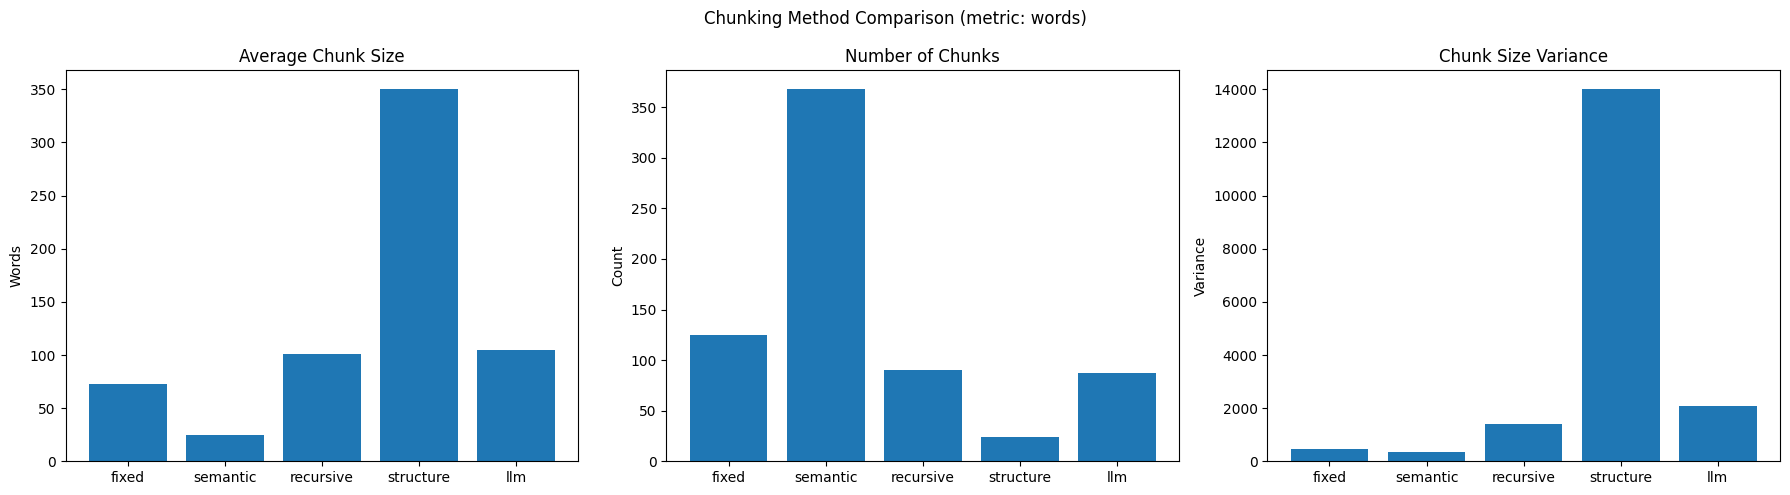

/tmp/ipykernel_14793/2701303536.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


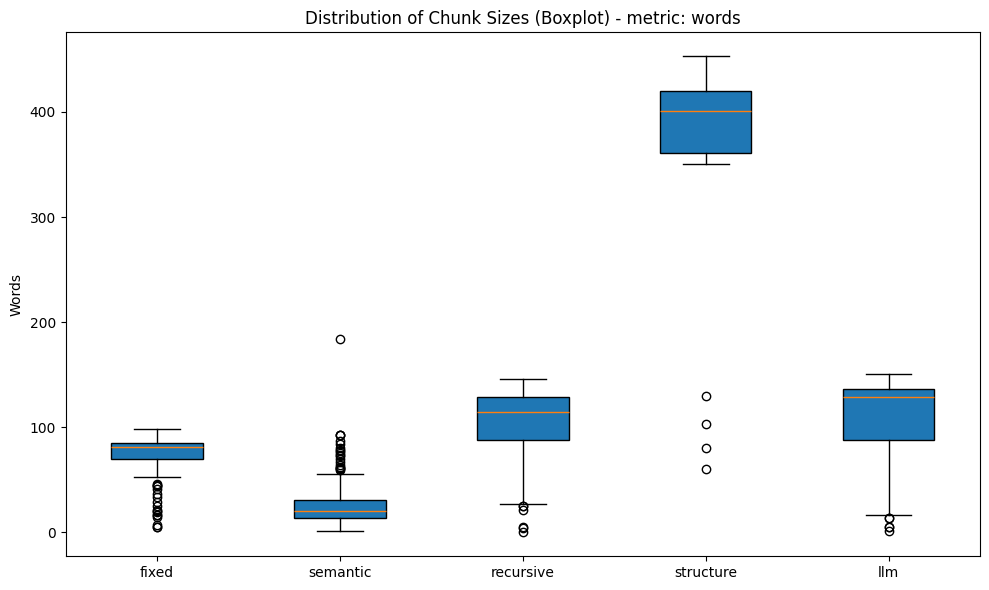

In [53]:
# ---- Bar Plots (use the computed df, no hardcoding) ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(df["Method"], df["Avg Chunk Size"])
axes[0].set_title("Average Chunk Size")
axes[0].set_ylabel({"chars":"Characters","words":"Words","tokens":"Tokens"}[METRIC])

axes[1].bar(df["Method"], df["Num Chunks"])
axes[1].set_title("Number of Chunks")
axes[1].set_ylabel("Count")

axes[2].bar(df["Method"], df["Size Variance"])
axes[2].set_title("Chunk Size Variance")
axes[2].set_ylabel("Variance")

plt.suptitle(f"Chunking Method Comparison (metric: {METRIC})")
plt.tight_layout()
plt.show()


# ---- Boxplot from raw chunk sizes (no hardcoding) ----
def extract_sizes(chunks, metric: str):
    return [_size_val(c, metric) for c in chunks]

sizes_fixed     = extract_sizes(chunked_pages, METRIC)
sizes_semantic  = extract_sizes(semantic_chunked_pages, METRIC)
sizes_recursive = extract_sizes(recursive_chunked_pages, METRIC)
sizes_structure = extract_sizes(structure_chunked_pages, METRIC)
sizes_llm       = extract_sizes(llm_chunked_pages, METRIC)

plt.figure(figsize=(10,6))
plt.boxplot(
    [sizes_fixed, sizes_semantic, sizes_recursive, sizes_structure, sizes_llm],
    labels=["fixed", "semantic", "recursive", "structure", "llm"],
    patch_artist=True
)
plt.title(f"Distribution of Chunk Sizes (Boxplot) - metric: {METRIC}")
plt.ylabel({"chars":"Characters","words":"Words","tokens":"Tokens"}[METRIC])
plt.tight_layout()
plt.show()